In [13]:
# =====================================================
# 0. Imports y setup
# =====================================================

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm
from matplotlib.colors import Normalize

sns.set(style="whitegrid")

# Ajusta la ruta según tu estructura de carpetas
# Supongamos:
#   project/
#      scripts/markov_engagement.py
#      notebooks/este_notebook.ipynb
sys.path.append("../scripts")

from markov_engagement import (
    build_transition_matrix,
    estacionaria,
    prob_mejorar,
    prob_empeorar,
    engagement_estacionario,
    DEFAULT_STATES,
)

states = DEFAULT_STATES  # [1, 2, 3, 4, 5]

## 1. Carga y preparación de datos

In [14]:
# Cargar el mismo CSV limpio
data = pd.read_csv("../data/data_globant_cleaned.csv")

# Asegurar formato de fecha
data["Date"] = pd.to_datetime(data["Date"])

# Filtrar estados válidos de Engagement Group (1..5)
data = data[data["Engagement Group"] > 0].copy()

# Ordenar por persona y tiempo (para transiciones correctas)
data = data.sort_values(["Name", "Date"])

data.head()

,Date,Name,Position,Seniority,Location,Studio,Client Tag,Project Tag,Team Name,Engagement,Leader Name,Engagement Group
6005,2023-01-02,Alberto Bravo,Data Analyst,Ssr,AR/CABA/BA,Data,EDUSYS,CATPRO,Star Wars: The Furry Awakens,3.40,Pedro Rodriguez,4
6006,2023-01-03,Alberto Bravo,Data Analyst,Ssr,AR/CABA/BA,Data,EDUSYS,CATPRO,Star Wars: The Furry Awakens,3.62,Pedro Rodriguez,4
6007,2023-01-04,Alberto Bravo,Data Analyst,Ssr,AR/CABA/BA,Data,EDUSYS,CATPRO,Star Wars: The Furry Awakens,3.73,Pedro Rodriguez,4
6008,2023-01-05,Alberto Bravo,Data Analyst,Ssr,AR/CABA/BA,Data,EDUSYS,CATPRO,Star Wars: The Furry Awakens,4.21,Pedro Rodriguez,5
6009,2023-01-06,Alberto Bravo,Data Analyst,Ssr,AR/CABA/BA,Data,EDUSYS,CATPRO,Star Wars: The Furry Awakens,3.91,Pedro Rodriguez,5


## 2. Función para obtener métricas de Markov por combinación de columnas

Vamos a crear una función `markov_summary_by_group` que:

- Recibe una lista de columnas de agrupamiento, por ejemplo:
  - `["Project Tag", "Seniority"]`
  - `["Project Tag", "Position", "Location"]`
- Para cada combinación de valores de esas columnas:
  - Filtra el subset.
  - Calcula matriz de transición, prob_mejorar, prob_empeorar, estacionaria, engagement_estacionario.
- Devuelve un DataFrame con una fila por combinación.

In [15]:
def markov_summary_by_group(df, group_cols, 
                            col_state="Engagement Group", 
                            states=states, 
                            min_rows=50):
    """
    Calcula métricas de cadenas de Markov por combinación de columnas.
    
    Parámetros:
    -----------
    df : DataFrame original con Name, Date, col_state y group_cols.
    group_cols : lista de columnas categóricas para agrupar (ej. ["Project Tag","Seniority"])
    col_state : nombre de la columna de estado (por defecto Engagement Group).
    states : lista de estados posibles (por defecto [1,2,3,4,5]).
    min_rows : mínimo de filas por grupo para considerarlo.
    
    Retorno:
    --------
    DataFrame con columnas:
      group_cols + ["n_registros", "prob_mejorar", "prob_empeorar", "engagement_estacionario"]
    """
    # Eliminar filas que tengan NaN en alguna de las columnas de grupo
    df_clean = df.dropna(subset=group_cols)

    results = []
    
    grouped = df_clean.groupby(group_cols)
    
    for combo_values, sub in grouped:
        # combo_values es una tupla si group_cols tiene más de 1 columna
        if isinstance(combo_values, tuple):
            combo_dict = {col: val for col, val in zip(group_cols, combo_values)}
        else:
            combo_dict = {group_cols[0]: combo_values}
        
        if sub.shape[0] < min_rows:
            continue
        
        P = build_transition_matrix(sub, col_state=col_state, states=states)
        if P.sum() == 0:
            continue
        
        pi = estacionaria(P)
        p_up = prob_mejorar(P, states=states)
        p_down = prob_empeorar(P, states=states)
        E_inf = engagement_estacionario(pi, states=states)
        
        row = {
            **combo_dict,
            "n_registros": sub.shape[0],
            "prob_mejorar": p_up,
            "prob_empeorar": p_down,
            "engagement_estacionario": E_inf
        }
        results.append(row)
    
    if not results:
        return pd.DataFrame(columns=group_cols + [
            "n_registros", "prob_mejorar", "prob_empeorar", "engagement_estacionario"
        ])
    
    res_df = pd.DataFrame(results)
    res_df = res_df.sort_values("engagement_estacionario", ascending=False).reset_index(drop=True)
    return res_df

## 3. Combinaciones sencillas: Project Tag + Seniority

In [16]:
group_cols_1 = ["Project Tag", "Seniority"]

df_proj_sen = markov_summary_by_group(
    data,
    group_cols=group_cols_1,
    col_state="Engagement Group",
    states=states,
    min_rows=30  # puedes ajustar
)

df_proj_sen.head(10)

,Project Tag,Seniority,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
0,CATPRO,Sr Level 3,126,0.348019,0.082081,4.539859
1,ODYQST,Jr,126,0.443062,0.046697,4.480000
2,HOREXP,Sr Level 3,124,0.346429,0.153848,4.138211
3,ECOSYS,Sr Level 1,126,0.257407,0.177778,3.890460
4,ECOSYS,Jr,123,0.244196,0.078048,3.596401
5,CATPRO,Sr Level 1,991,0.229081,0.142798,3.511286
6,NEXDEV,Jr,458,0.281034,0.141804,3.478449
7,NEXDEV,Sr Level 1,1129,0.304056,0.224814,3.443441
8,VGRDIN,Sr Level 1,161,0.369998,0.282424,3.409786
9,ODYQST,Sr Level 1,377,0.277652,0.181334,3.363210


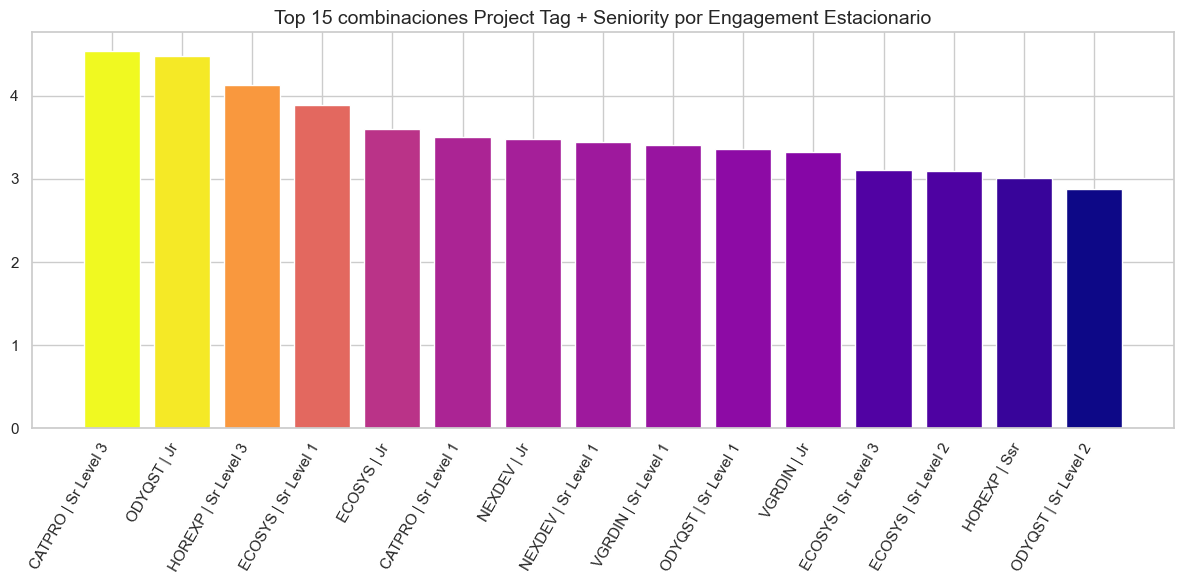

In [17]:
fig, ax = plt.subplots(figsize=(12,6))
vals = df_proj_sen["engagement_estacionario"].head(15)
norm = Normalize(vmin=vals.min(), vmax=vals.max())
colors = cm.plasma(norm(vals))

ax.bar(
    df_proj_sen.iloc[:15].apply(lambda r: f"{r['Project Tag']} | {r['Seniority']}", axis=1),
    vals, color=colors
)

ax.set_title("Top 15 combinaciones Project Tag + Seniority por Engagement Estacionario", fontsize=14)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

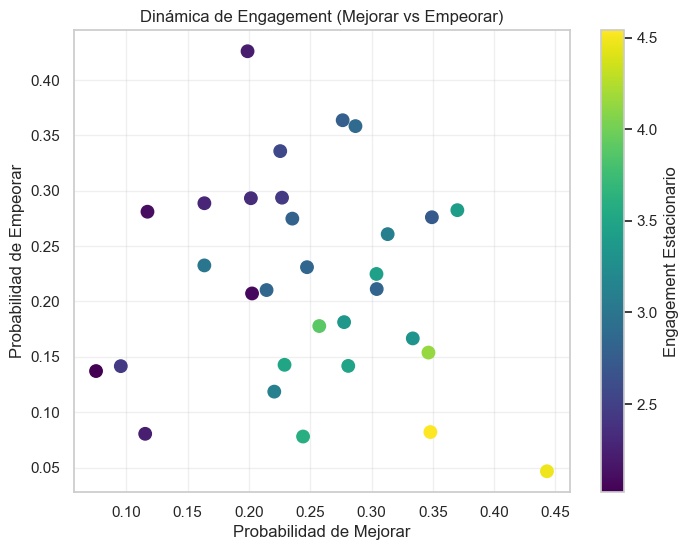

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(df_proj_sen["prob_mejorar"], df_proj_sen["prob_empeorar"],
            c=df_proj_sen["engagement_estacionario"], cmap="viridis", s=80)
plt.colorbar(label="Engagement Estacionario")

plt.xlabel("Probabilidad de Mejorar")
plt.ylabel("Probabilidad de Empeorar")
plt.title("Dinámica de Engagement (Mejorar vs Empeorar)")
plt.grid(True, alpha=0.3)
plt.show()

### 3.1 Vista rápida de las mejores y peores combinaciones Project Tag + Seniority

In [18]:
top_10_proj_sen = df_proj_sen.head(10)
bottom_10_proj_sen = df_proj_sen.tail(10)

print("TOP 10 combinaciones Project Tag + Seniority por engagement estacionario:")
display(top_10_proj_sen)

print("BOTTOM 10 combinaciones Project Tag + Seniority:")
display(bottom_10_proj_sen)

TOP 10 combinaciones Project Tag + Seniority por engagement estacionario:


,Project Tag,Seniority,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
0,CATPRO,Sr Level 3,126,0.348019,0.082081,4.539859
1,ODYQST,Jr,126,0.443062,0.046697,4.480000
2,HOREXP,Sr Level 3,124,0.346429,0.153848,4.138211
3,ECOSYS,Sr Level 1,126,0.257407,0.177778,3.890460
4,ECOSYS,Jr,123,0.244196,0.078048,3.596401
5,CATPRO,Sr Level 1,991,0.229081,0.142798,3.511286
6,NEXDEV,Jr,458,0.281034,0.141804,3.478449
7,NEXDEV,Sr Level 1,1129,0.304056,0.224814,3.443441
8,VGRDIN,Sr Level 1,161,0.369998,0.282424,3.409786
9,ODYQST,Sr Level 1,377,0.277652,0.181334,3.363210


BOTTOM 10 combinaciones Project Tag + Seniority:


,Project Tag,Seniority,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
21,NEXDEV,Ssr,552,0.225567,0.335729,2.564122
22,CATPRO,Ssr,752,0.227037,0.293681,2.444096
23,HOREXP,Sr Level 1,368,0.095572,0.141591,2.442116
24,STYPRJ,Sr Level 1,368,0.201640,0.293197,2.331742
25,STYPRJ,Sr Level 2,375,0.163721,0.288677,2.278233
26,HOREXP,Jr,126,0.115455,0.080505,2.225686
27,VGRDIN,Sr Level 2,246,0.198926,0.425889,2.215022
28,ATLINT,Ssr,742,0.117321,0.281010,2.100078
29,ECOSYS,Ssr,246,0.202601,0.207222,2.072339
30,ODYQST,Ssr,252,0.075387,0.137151,2.018028


## 4. Combinación más rica: Project Tag + Seniority + Position + Location

Aquí intentamos capturar más contexto del empleado:
- En qué proyecto está,
- Qué nivel de seniority tiene,
- Qué posición (rol),
- En qué ubicación trabaja.

Cada fila del resultado será una combinación de:
`(Project Tag, Seniority, Position, Location)`.

Cada combinación tendrá sus métricas de cadena de Markov.

In [19]:
group_cols_2 = ["Project Tag", "Seniority", "Position", "Location"]

df_combo = markov_summary_by_group(
    data,
    group_cols=group_cols_2,
    col_state="Engagement Group",
    states=states,
    min_rows=40  # un poco más alto para tener grupos más robustos
)

print("Shape df_combo:", df_combo.shape)
df_combo.head()

Shape df_combo: (90, 8)


,Project Tag,Seniority,Position,Location,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
0,CATPRO,Sr Level 2,Data Analyst,AR/CABA/BA,147,0.279304,0.158018,5.000000
1,CATPRO,Sr Level 1,Visual Designer,CO/CUN/BOG,68,0.000000,0.002985,4.985075
2,HOREXP,Sr Level 1,Project Manager,CL/RM/SCL,126,0.100000,0.103670,4.599089
3,VGRDIN,Ssr,Business Analyst,CO/CUN/BOG,126,0.335227,0.159853,4.503661
4,ODYQST,Jr,Business Analyst,CL/RM/SCL,126,0.443062,0.046697,4.480000


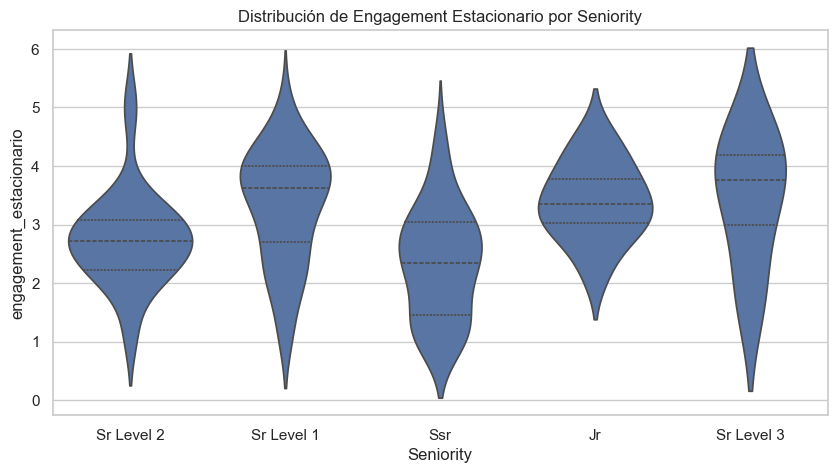

In [26]:
plt.figure(figsize=(10,5))
sns.violinplot(data=df_combo, x="Seniority", y="engagement_estacionario", inner="quart")
plt.title("Distribución de Engagement Estacionario por Seniority")
plt.show()

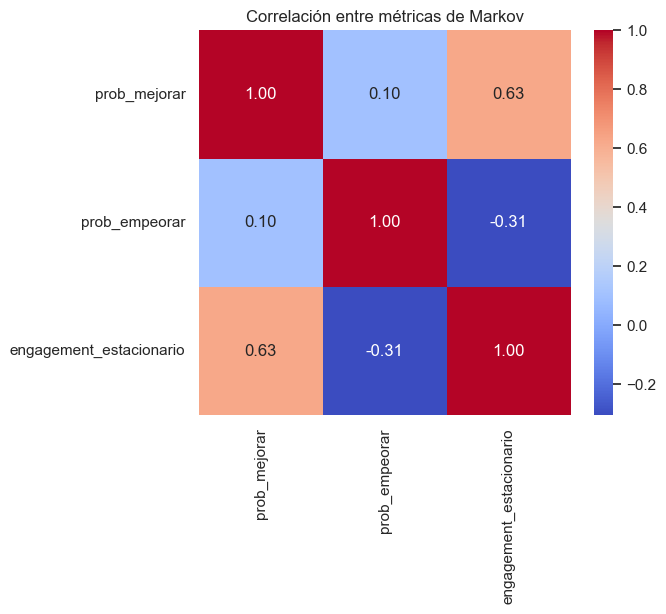

In [27]:
corr = df_combo[["prob_mejorar", "prob_empeorar", "engagement_estacionario"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre métricas de Markov")
plt.show()

### 4.1 Explorar algunas combinaciones con más registros

In [20]:
df_combo_sorted_n = df_combo.sort_values("n_registros", ascending=False)
df_combo_sorted_n.head(10)

,Project Tag,Seniority,Position,Location,n_registros,prob_mejorar,prob_empeorar,engagement_estacionario
43,NEXDEV,Jr,Software Developer,AR/CABA/BA,252,0.213551,0.153038,2.997068
80,CATPRO,Ssr,Software Developer,CO/ANT/MED,251,0.052809,0.129577,1.289544
30,NEXDEV,Sr Level 1,Software Developer,AR/CABA/BA,251,0.345957,0.276678,3.374468
57,STYPRJ,Ssr,Software Developer,CO/CUN/BOG,236,0.326873,0.276133,2.615627
32,ODYQST,Sr Level 1,Software Developer,AR/CABA/BA,208,0.223234,0.193455,3.224582
25,NEXDEV,Sr Level 1,Quality Assurance Tester,CO/CUN/BOG,166,0.432814,0.246667,3.557576
0,CATPRO,Sr Level 2,Data Analyst,AR/CABA/BA,147,0.279304,0.158018,5.000000
13,ATLINT,Ssr,Software Developer,MX/CDMX/CDMX,135,0.309444,0.136122,4.034483
41,CATPRO,Ssr,Data Analyst,AR/CABA/BA,130,0.307536,0.290134,3.040048
45,ATLINT,Sr Level 1,Quality Assurance Tester,MX/CDMX/CDMX,130,0.285725,0.405575,2.901780


## 5. Modelo: ¿qué influye en el engagement estacionario?

Idea del modelo:

- Cada fila de `df_combo` es una combinación `(Project Tag, Seniority, Position, Location)`.
- Target (variable a explicar):
  - `engagement_estacionario`
  - (Opcional) también podríamos modelar `prob_mejorar` o `prob_empeorar`.
- Features (predictoras):
  - Variables categóricas: Project Tag, Seniority, Position, Location.
  - Las codificamos con one-hot (`get_dummies`).

Vamos a usar una **regresión lineal** para:
- Obtener un R² básico.
- Ver coeficientes asociados a cada categórica (qué grupos empujan hacia arriba o abajo).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

df_model = df_combo.copy()

# Target
y = df_model["engagement_estacionario"].values

# Features
X_cat = df_model[["Project Tag", "Seniority", "Position", "Location"]].astype(str)
X = pd.get_dummies(X_cat, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

linreg = LinearRegression().fit(X_train, y_train)

print("R² Train:", linreg.score(X_train, y_train))
print("R² Test:", linreg.score(X_test, y_test))

In [ ]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": linreg.coef_
}).sort_values("coef")

plt.figure(figsize=(8,12))
plt.barh(coef_df["feature"].tail(20), coef_df["coef"].tail(20), color="seagreen")
plt.title("Top 20 Variables con Influencia Positiva en Engagement Estacionario")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,12))
plt.barh(coef_df["feature"].head(20), coef_df["coef"].head(20), color="firebrick")
plt.title("Top 20 Variables con Influencia Negativa")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

### 5.1 Importancia de variables vía coeficientes

En regresión lineal con dummies:

- Un coeficiente positivo significa:
  - Esa categoría (por ejemplo, cierta combinación de `Project Tag` o `Position`) se asocia a un **mayor** engagement estacionario, comparado con la categoría base.
- Un coeficiente negativo significa:
  - Esa categoría tiende a reducir el engagement estacionario respecto a la base.

Vamos a listar los coeficientes ordenados.

In [23]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coef": linreg.coef_
})

coef_df_sorted = coef_df.sort_values("coef", ascending=False)

print("Top 15 features con coeficientes más positivos:")
display(coef_df_sorted.head(15))

print("\nTop 15 features con coeficientes más negativos:")
display(coef_df_sorted.tail(15))

Top 15 features con coeficientes más positivos:


,feature,coef
27,Location_CO/CUN/BOG,0.929198
16,Position_Product Owner,0.736867
14,Position_Database Administrator,0.713207
29,Location_MX/JALISCO/GDL,0.504449
28,Location_MX/CDMX/CDMX,0.310009
13,Position_Data Analyst,0.269947
22,Position_Test Automation Engineer,0.235660
25,Location_CL/RM/SCL,0.217018
11,Position_Business Intelligence,0.190239
23,Position_User Experience Designer,0.182085



Top 15 features con coeficientes más negativos:


,feature,coef
3,Project Tag_NEXDEV,-0.046106
20,Position_Solutions Architect,-0.290050
9,Seniority_Sr Level 3,-0.290050
1,Project Tag_ECOSYS,-0.413616
18,Position_Quality Assurance Tester,-0.440750
19,Position_Software Developer,-0.444044
15,Position_DevOps Engineer,-0.549932
5,Project Tag_STYPRJ,-0.641871
7,Seniority_Sr Level 1,-0.747992
17,Position_Project Manager,-0.769814


## 6. (Opcional) Modelo sobre prob_mejorar o neto (prob_mejorar - prob_empeorar)

Podemos repetir el mismo esquema tomando como target:

- `prob_mejorar`
- `prob_empeorar`
- o un score neto: `prob_mejorar - prob_empeorar`

In [28]:
df_model["score_neto"] = df_model["prob_mejorar"] - df_model["prob_empeorar"]
y_net = df_model["score_neto"].values

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X, y_net, test_size=0.3)
linreg_net = LinearRegression().fit(X_train_n, y_train_n)

print("R² Train (score_neto):", linreg_net.score(X_train_n, y_train_n))
print("R² Test (score_neto):", linreg_net.score(X_test_n, y_test_n))

R² Train (score_neto): 0.516742517349563
R² Test (score_neto): 0.4569063209283084


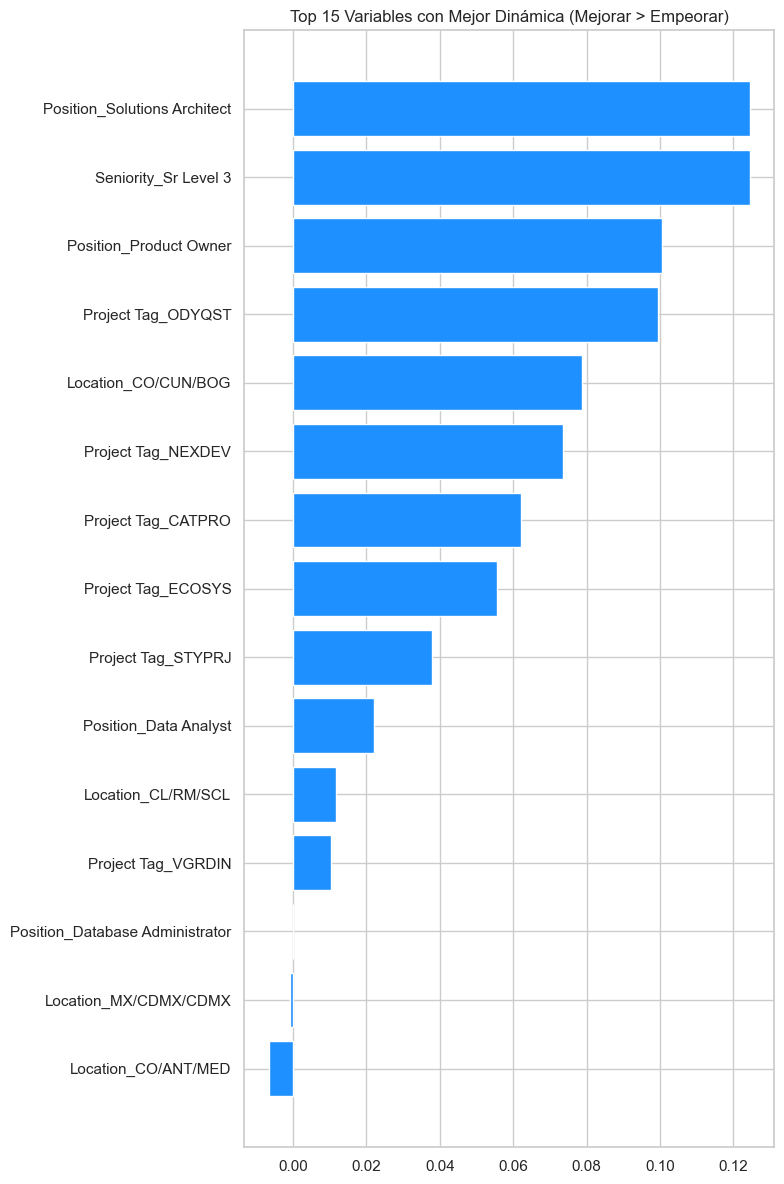

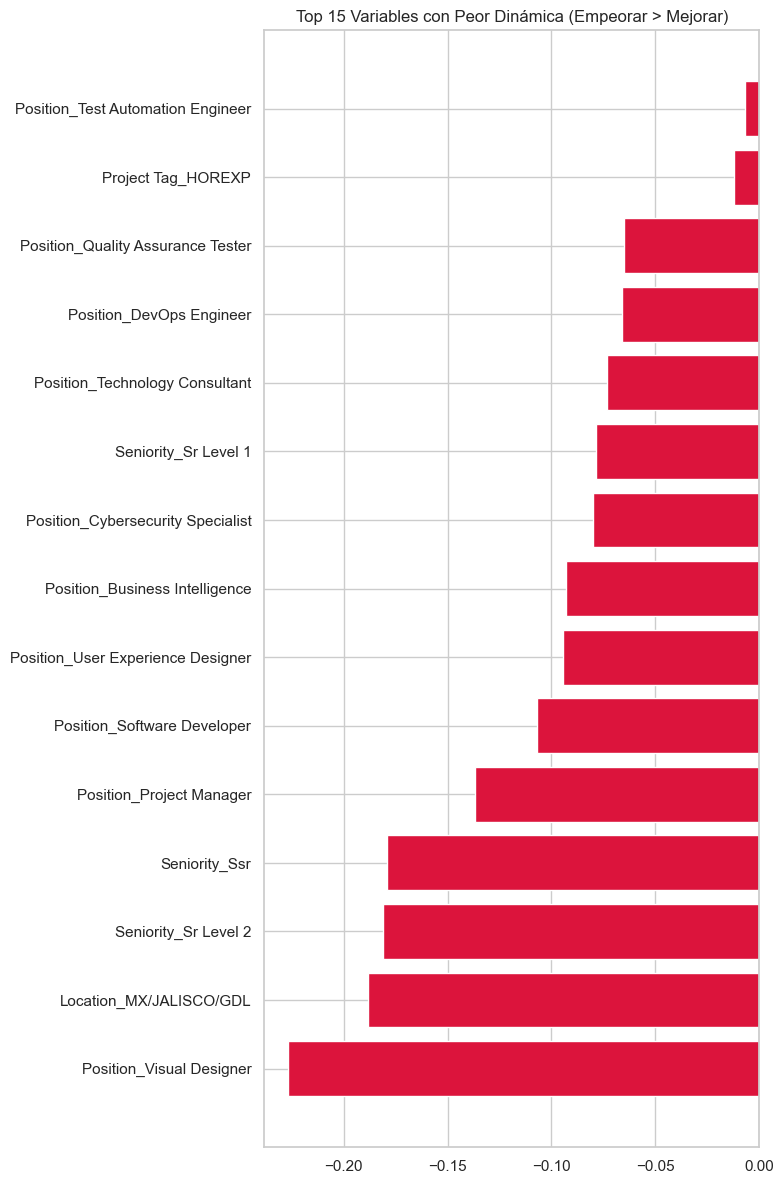

In [29]:
coef_net = pd.DataFrame({
    "feature": X.columns,
    "coef": linreg_net.coef_
}).sort_values("coef")

plt.figure(figsize=(8,12))
plt.barh(coef_net["feature"].tail(15), coef_net["coef"].tail(15), color="dodgerblue")
plt.title("Top 15 Variables con Mejor Dinámica (Mejorar > Empeorar)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,12))
plt.barh(coef_net["feature"].head(15), coef_net["coef"].head(15), color="crimson")
plt.title("Top 15 Variables con Peor Dinámica (Empeorar > Mejorar)")
plt.tight_layout()
plt.show()

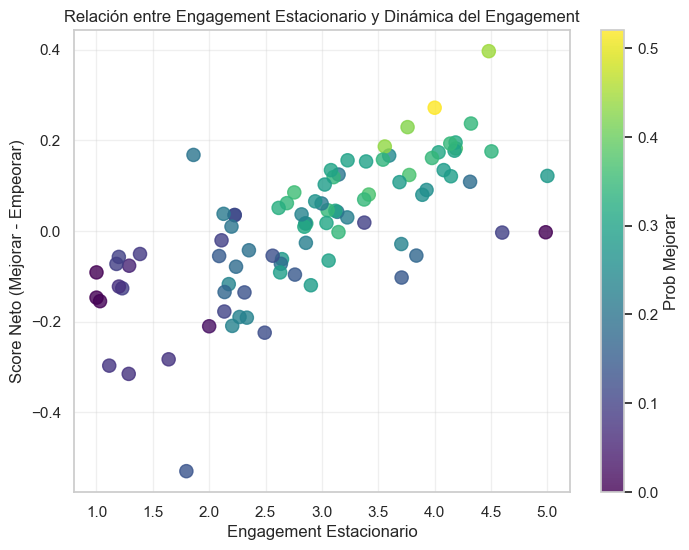

In [32]:
df_model = df_combo.copy()
df_model["score_neto"] = df_model["prob_mejorar"] - df_model["prob_empeorar"]

plt.figure(figsize=(8,6))
plt.scatter(
    df_combo["engagement_estacionario"],
    df_combo["score_neto"],
    c=df_combo["prob_mejorar"], cmap="viridis", s=90, alpha=0.8
)
plt.colorbar(label="Prob Mejorar")
plt.xlabel("Engagement Estacionario")
plt.ylabel("Score Neto (Mejorar - Empeorar)")
plt.title("Relación entre Engagement Estacionario y Dinámica del Engagement")
plt.grid(alpha=0.3)
plt.show()

## 7. ¿Cómo interpretar todo esto en términos de “qué influye en el engagement”?

A partir de los resultados del modelo:

- Las categorías (Project Tag, Seniority, Position, Location) con **coeficientes positivos**:
  - Son combinaciones asociadas a niveles más altos de engagement estacionario o a mayor score_neto (más probabilidad de mejorar que de empeorar).
- Las categorías con **coeficientes negativos**:
  - Indican grupos que tienden a tener menor engagement estacionario o más riesgo de caída.

En el reporte, se puede traducir en frases del tipo:

- “Los proyectos de tipo X con roles Y en la ubicación Z tienden a sostener o mejorar el engagement en el tiempo.”
- “Las combinaciones de Project Tag A + Seniority Jr + Position B muestran menor engagement de largo plazo y un balance negativo entre probabilidad de mejora y empeoramiento.”

---

## 8. Siguientes pasos recomendados

1. **Revisar estabilidad del modelo**
   - Probar distintos valores de `min_rows` para ver si los coeficientes son razonablemente estables.
   - Revisar si hay combos muy raros (pocos registros) que puedan sesgar.

2. **Limpiar / agrupar categorías**
   - Agrupar posiciones muy específicas en categorías más generales (ej. “Tech roles” vs “Business roles”).
   - Agrupar ubicaciones pequeñas a nivel país o región.

3. **Probar otros modelos (si quieren ir más allá)**
   - Random Forest Regressor para tener importancia de variables basada en árboles.
   - Regularización (Ridge/Lasso) para estabilizar coeficientes si hay muchas dummies.

4. **Conectar con decisiones**
   - Identificar:
     - Combinaciones “favorables” → ejemplos de buenas prácticas de proyecto / rol / ubicación.
     - Combinaciones “críticas” → candidatos a intervenciones (cambio de líder, mentoring, rotación de proyecto, etc.).

5. **Integrar esto al reporte final**
   - Mostrar:
     - 1–2 tablas de combinaciones top/bottom.
     - 1 gráfica de importancia de features (los coeficientes más grandes en magnitud).
   - Resumir en lenguaje de negocio:
     - qué tipo de proyectos / roles / seniorities influyen más en tener engagement alto o bajo en el tiempo.